# Calories Burnt Prediction

## Data Loading and Preprocessing

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

In [3]:
calories_df = pd.read_csv('../data/calories.csv')
exercise_df = pd.read_csv('../data/exercise.csv')

In [4]:
calories_df.head()

,User_ID,Calories
0,14733363,231.0
1,14861698,66.0
2,11179863,26.0
3,16180408,71.0
4,17771927,35.0


In [5]:
exercise_df.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8


In [6]:
df = pd.merge(exercise_df, calories_df, how='outer')

In [7]:
df.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,10001159,female,67,176.0,74.0,12.0,103.0,39.6,76.0
1,10001607,female,34,178.0,79.0,19.0,96.0,40.6,93.0
2,10005485,female,38,178.0,77.0,14.0,82.0,40.5,49.0
3,10005630,female,39,169.0,66.0,8.0,90.0,39.6,36.0
4,10006441,male,23,169.0,73.0,25.0,102.0,40.7,122.0


In [30]:
df.drop(['User_ID'], axis=1, inplace=True)

In [31]:
df.shape

(15000, 8)

## Exploratory Data Analysis

In [32]:
df.describe()

,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,42.789800,174.465133,74.966867,15.530600,95.518533,40.025453,89.539533
std,16.980264,14.258114,15.035657,8.319203,9.583328,0.779230,62.456978
min,20.000000,123.000000,36.000000,1.000000,67.000000,37.100000,1.000000
25%,28.000000,164.000000,63.000000,8.000000,88.000000,39.600000,35.000000
50%,39.000000,175.000000,74.000000,16.000000,96.000000,40.200000,79.000000
75%,56.000000,185.000000,87.000000,23.000000,103.000000,40.600000,138.000000
max,79.000000,222.000000,132.000000,30.000000,128.000000,41.500000,314.000000


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Gender      15000 non-null  object 
 1   Age         15000 non-null  int64  
 2   Height      15000 non-null  float64
 3   Weight      15000 non-null  float64
 4   Duration    15000 non-null  float64
 5   Heart_Rate  15000 non-null  float64
 6   Body_Temp   15000 non-null  float64
 7   Calories    15000 non-null  float64
dtypes: float64(6), int64(1), object(1)
memory usage: 937.6+ KB


In [38]:
# Assuming height and weight units as cm and kg,
df['BMI'] = df['Weight'] / df['Height']

In [39]:
df.drop(['Weight', 'Height'], axis=1, inplace=True)

In [40]:
df.head()

,Gender,Age,Duration,Heart_Rate,Body_Temp,Calories,BMI
0,female,67,12.0,103.0,39.6,76.0,0.420455
1,female,34,19.0,96.0,40.6,93.0,0.443820
2,female,38,14.0,82.0,40.5,49.0,0.432584
3,female,39,8.0,90.0,39.6,36.0,0.390533
4,male,23,25.0,102.0,40.7,122.0,0.431953


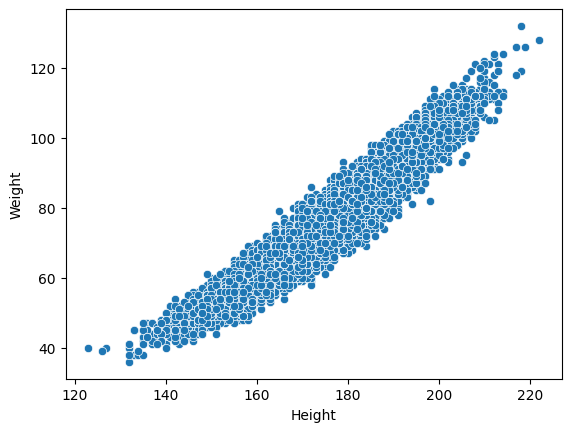

In [34]:
sb.scatterplot(x=df['Height'], y=df['Weight'])
plt.show()

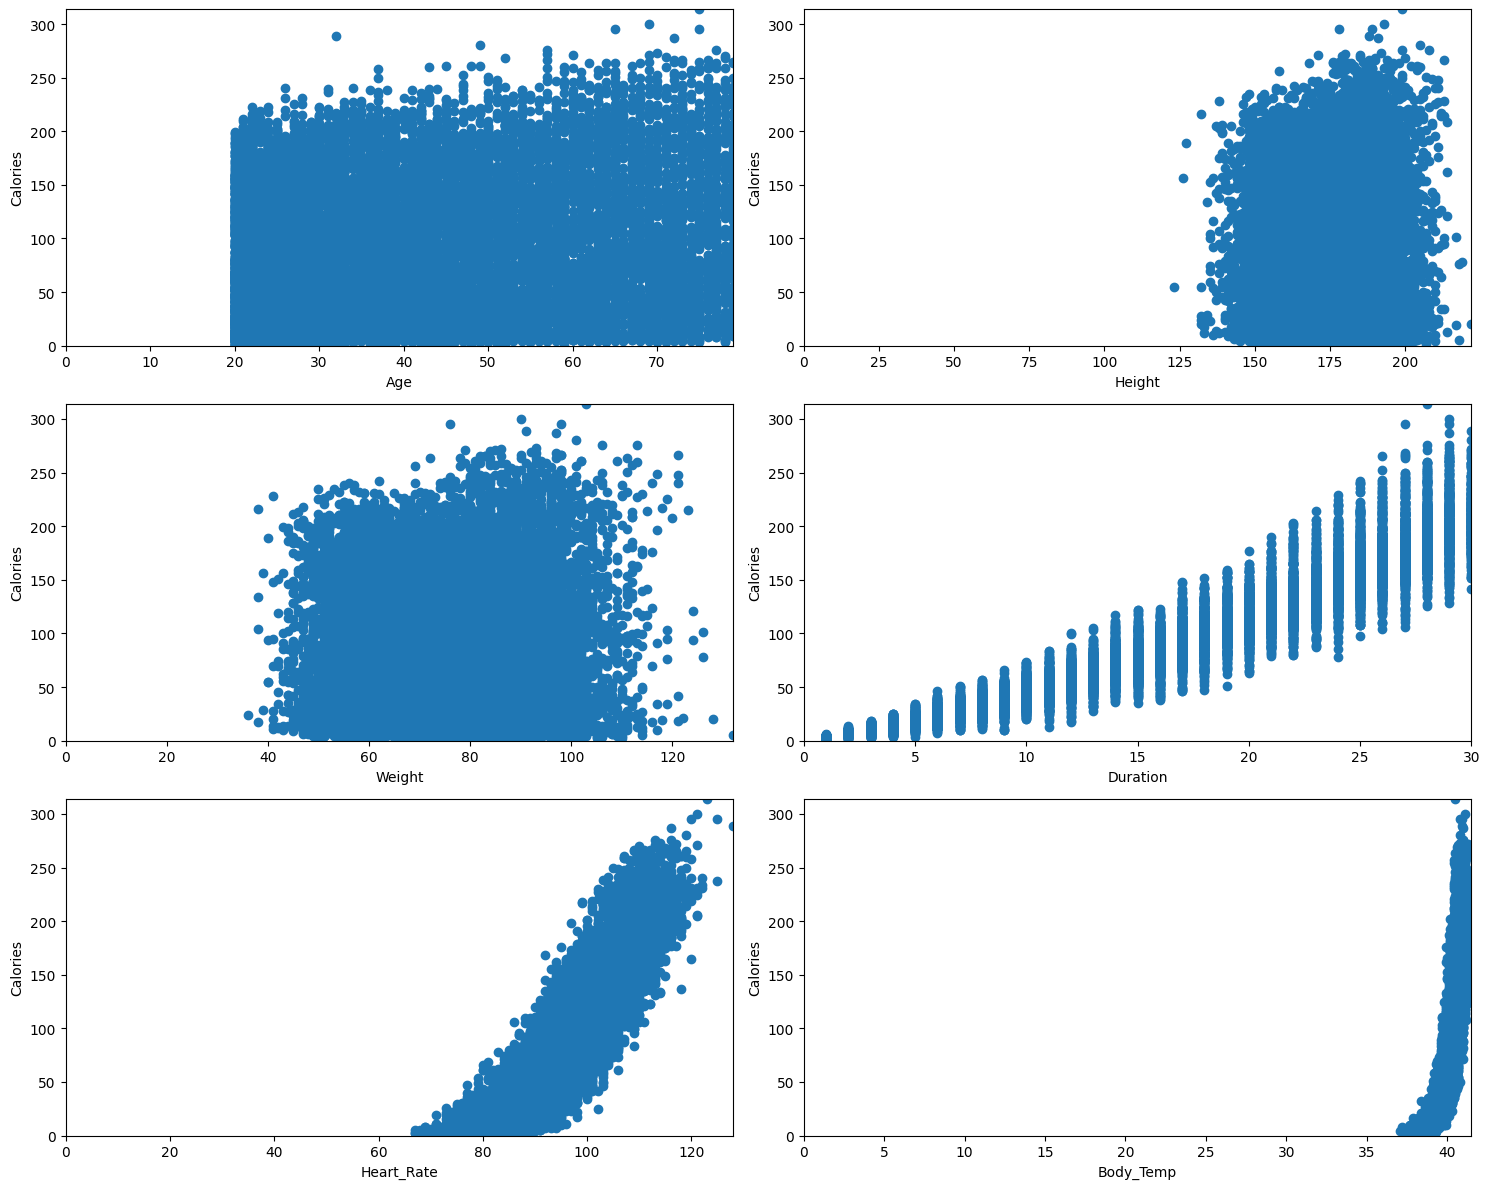

In [35]:
features = ['Age', 'Height', 'Weight', 'Duration', 'Heart_Rate', 'Body_Temp']

fig, axs = plt.subplots(3, 2, figsize=(15,12))
i=0

for r in range(3):
    for c in range(2):
        col = features[i]
        axs[r][c].axis([0.0, max(df[col]), 0.0, max(df['Calories'])])
        axs[r][c].scatter(x=df[col], y=df['Calories'])
        axs[r][c].set_xlabel(col)
        axs[r][c].set_ylabel('Calories')
        i+=1
    
plt.tight_layout()
plt.show()

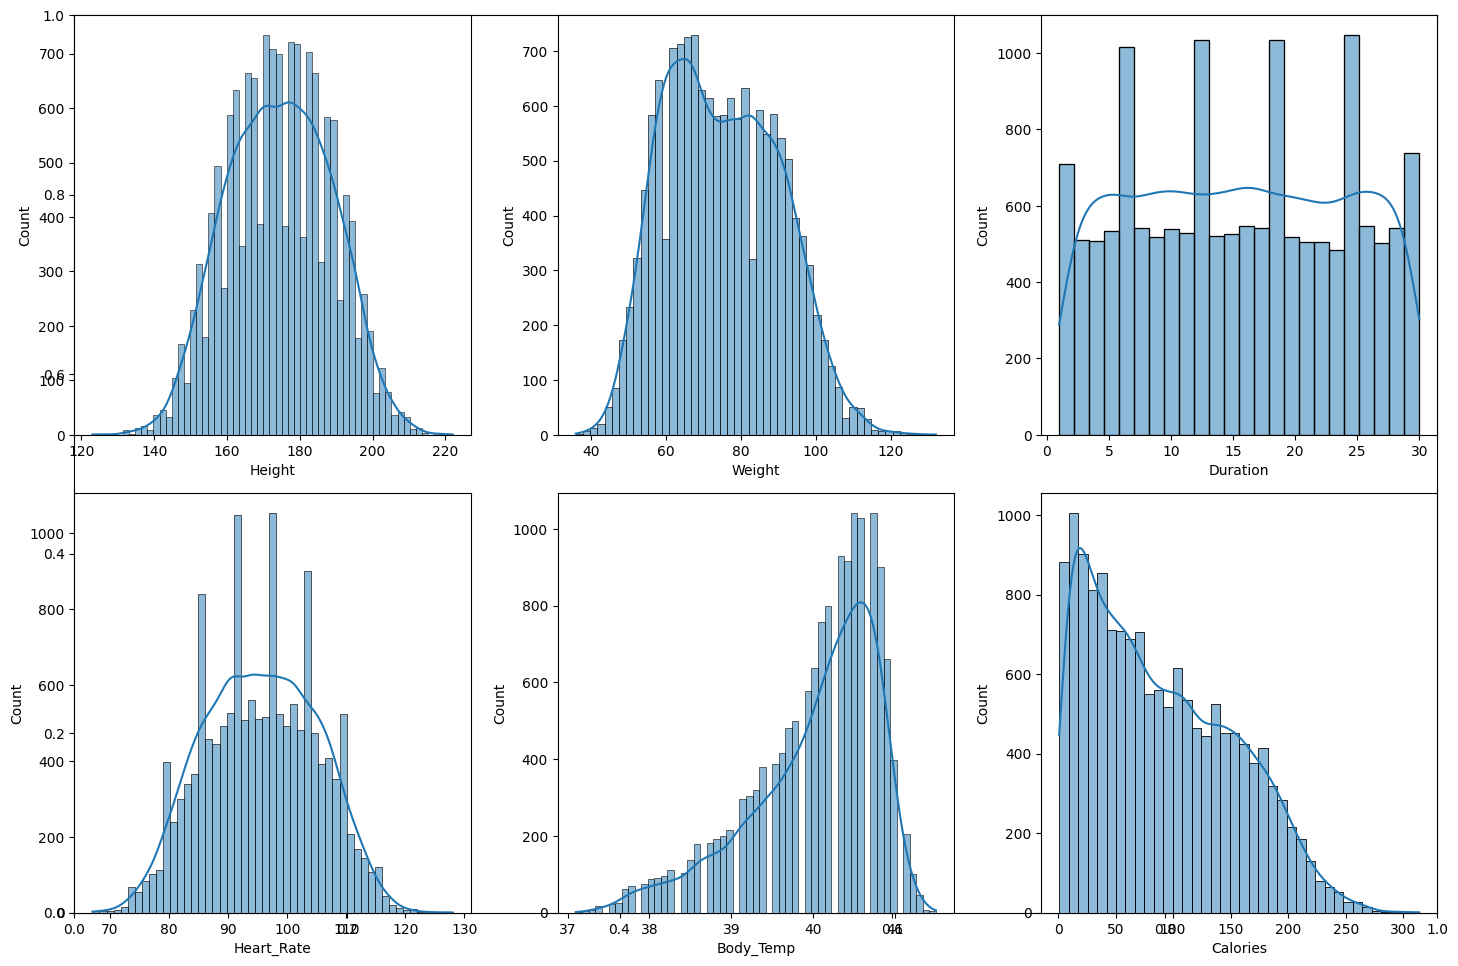

In [36]:
features1 = df.select_dtypes(include='float').columns

plt.subplots(figsize=(15,10))

for i, col in enumerate(features1):
  plt.subplot(2,3,i+1)
  sb.histplot(x = df[col], kde = True)

plt.tight_layout()
plt.show()

In [41]:
from sklearn.preprocessing import LabelEncoder
label_enc = LabelEncoder()
df['Gender'] = label_enc.fit_transform(df['Gender'])

In [42]:
df.head()

,Gender,Age,Duration,Heart_Rate,Body_Temp,Calories,BMI
0,0,67,12.0,103.0,39.6,76.0,0.420455
1,0,34,19.0,96.0,40.6,93.0,0.443820
2,0,38,14.0,82.0,40.5,49.0,0.432584
3,0,39,8.0,90.0,39.6,36.0,0.390533
4,1,23,25.0,102.0,40.7,122.0,0.431953


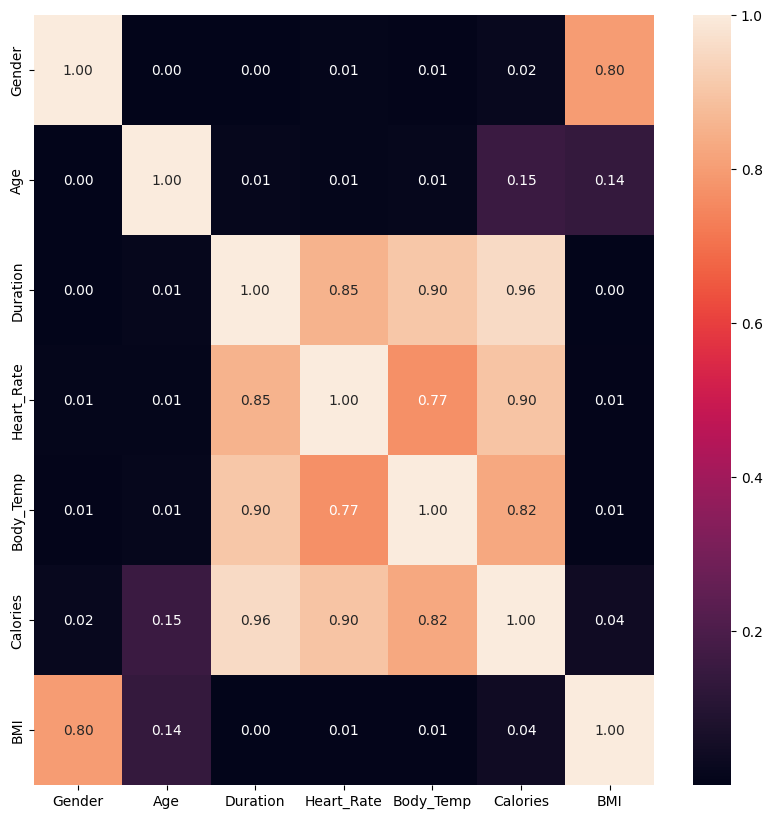

In [43]:
plt.figure(figsize=(10,10))
sb.heatmap(df.corr(numeric_only=True), annot=True, cbar=True, fmt='.2f')
plt.show()

In [44]:
from sklearn.model_selection import train_test_split

In [45]:
X = df.drop(['Calories'], axis=1)
Y = df['Calories']

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size = 0.25, random_state = 42)

In [46]:
x_train.shape, x_test.shape

((11250, 6), (3750, 6))

In [48]:
from sklearn.preprocessing import StandardScaler

In [49]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [58]:
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error as mae
from sklearn.metrics import r2_score

In [59]:
lr = LinearRegression()
lasso = Lasso()
ridge = Ridge()
dtr = DecisionTreeRegressor()
rfr = RandomForestRegressor()
knr = KNeighborsRegressor()

In [60]:
lr.fit(x_train_scaled, y_train)
lasso.fit(x_train_scaled, y_train)
ridge.fit(x_train_scaled, y_train)
dtr.fit(x_train_scaled, y_train)
rfr.fit(x_train_scaled, y_train)
knr.fit(x_train_scaled, y_train)

KNeighborsRegressor()

In [61]:
lr_preds = lr.predict(x_test_scaled)
lasso_preds = lasso.predict(x_test_scaled)
ridge_preds = ridge.predict(x_test_scaled)
dtr_preds = dtr.predict(x_test_scaled)
rfr_preds = rfr.predict(x_test_scaled)
knr_preds = knr.predict(x_test_scaled)

In [67]:
print("R2_Scores -->\n")
print(f'LR: {round(r2_score(y_test, lr_preds), 5) * 100} %')
print(f'Lasso: {round(r2_score(y_test, lasso_preds), 5) * 100} %')
print(f'Ridge: {round(r2_score(y_test, ridge_preds), 5) * 100} %')
print(f'DTR: {round(r2_score(y_test, dtr_preds), 5) * 100} %')
print(f'RFR: {round(r2_score(y_test, rfr_preds), 5) * 100} %')
print(f'KNR: {round(r2_score(y_test, knr_preds), 5) * 100} %')

R2_Scores -->

LR: 96.685 %
Lasso: 96.098 %
Ridge: 96.685 %
DTR: 99.32 %
RFR: 99.786 %
KNR: 99.423 %


In [70]:
print('Mean Squared Errors -->\n')
print(f'LR: {round(mae(y_test, lr_preds), 5)}')
print(f'Lasso: {round(mae(y_test, lasso_preds), 5)}')
print(f'Ridge: {round(mae(y_test, ridge_preds), 5)}')
print(f'DTR: {round(mae(y_test, dtr_preds), 5)}')
print(f'RFR: {round(mae(y_test, rfr_preds), 5)}')
print(f'KNR: {round(mae(y_test, knr_preds), 5)}')

Mean Squared Errors -->

LR: 8.45165
Lasso: 9.122
Ridge: 8.45132
DTR: 3.3992
RFR: 1.88395
KNR: 3.48139


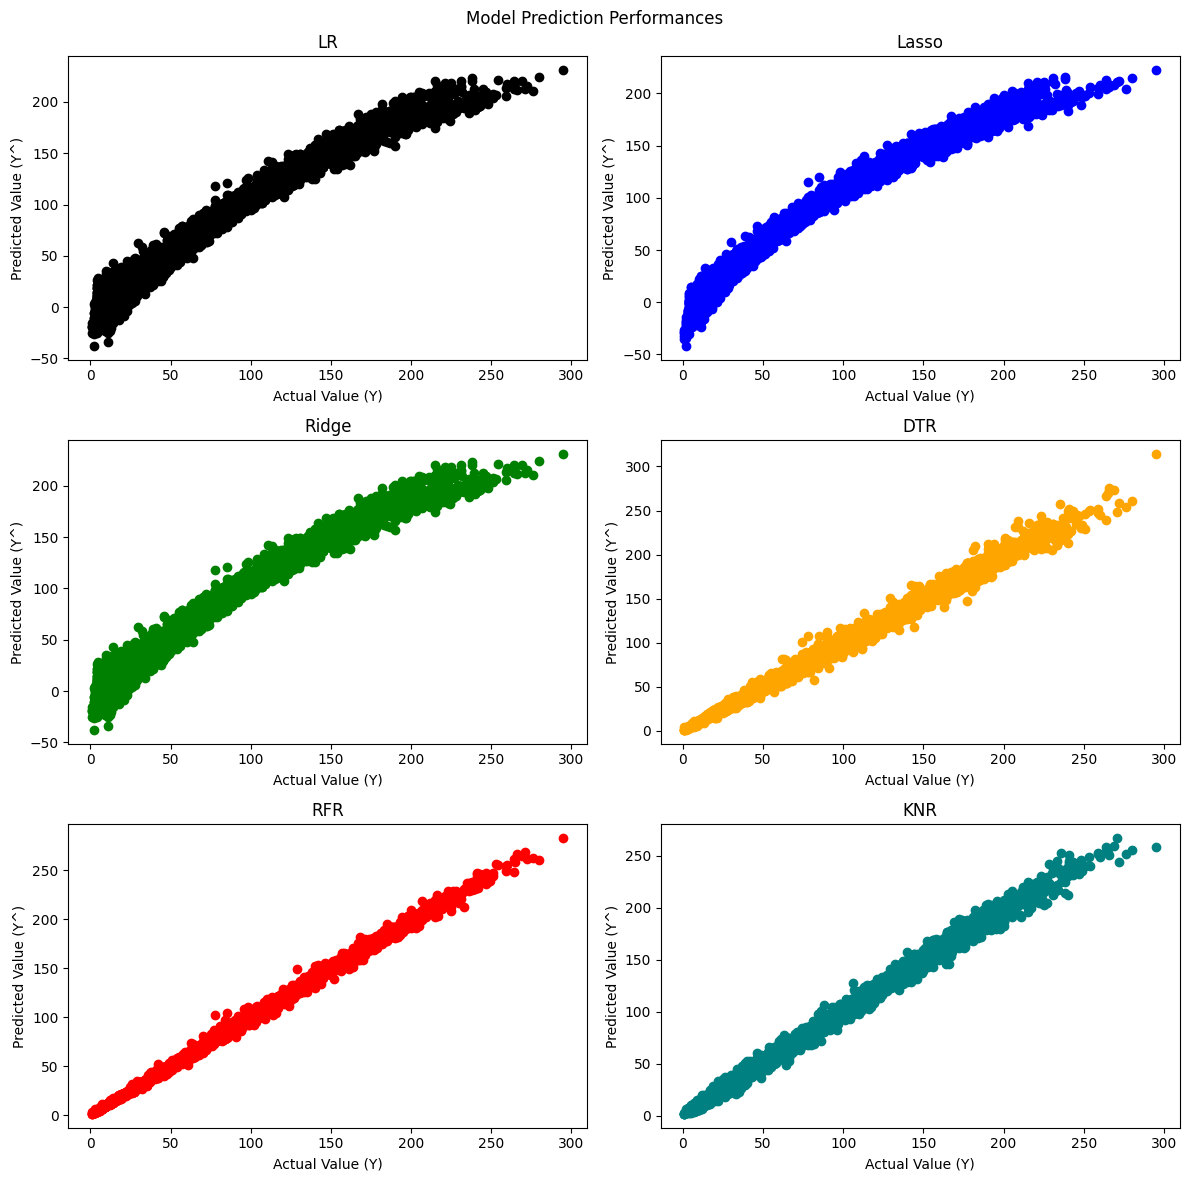

In [71]:
fig, axs = plt.subplots(3, 2, figsize=(12, 12))
fig.suptitle('Model Prediction Performances')

axs[0][0].set_title('LR')
axs[0][0].scatter(y_test, lr_preds, color='black')
axs[0][0].set_xlabel('Actual Value (Y)')
axs[0][0].set_ylabel('Predicted Value (Y^)')

axs[0][1].set_title('Lasso')
axs[0][1].scatter(y_test, lasso_preds, color='blue')
axs[0][1].set_xlabel('Actual Value (Y)')
axs[0][1].set_ylabel('Predicted Value (Y^)')

axs[1][0].set_title('Ridge')
axs[1][0].scatter(y_test, ridge_preds, color='green')
axs[1][0].set_xlabel('Actual Value (Y)')
axs[1][0].set_ylabel('Predicted Value (Y^)')

axs[1][1].set_title('DTR')
axs[1][1].scatter(y_test, dtr_preds, color='orange')
axs[1][1].set_xlabel('Actual Value (Y)')
axs[1][1].set_ylabel('Predicted Value (Y^)')

axs[2][0].set_title('RFR')
axs[2][0].scatter(y_test, rfr_preds, color='red')
axs[2][0].set_xlabel('Actual Value (Y)')
axs[2][0].set_ylabel('Predicted Value (Y^)')

axs[2][1].set_title('KNR')
axs[2][1].scatter(y_test, knr_preds, color='teal')
axs[2][1].set_xlabel('Actual Value (Y)')
axs[2][1].set_ylabel('Predicted Value (Y^)')

plt.tight_layout()
plt.savefig('../reports/model_performances.png')


In [73]:
# best models 1. rfr    2. dtr    3. knr

from pickle import dump

with open('../models/trained_rfr_model.pkl', 'wb') as f:
    dump(rfr, f)

with open('../models/trained_dtr_model.pkl', 'wb') as f:
    dump(dtr, f)

with open('../models/trained_knr_model.pkl', 'wb') as f:
    dump(knr, f)
